Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Load The Datasets

In [2]:
matches = pd.read_csv('../DATA1/matches.csv')
deliveries = pd.read_csv('../DATA1/deliveries.csv')


Look at the Data

In [3]:
matches.head()


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
deliveries.head()


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


Dataset shape

In [5]:
matches.shape


(1095, 20)

In [6]:
deliveries.shape


(260920, 17)

Check columns

In [7]:
matches.columns


Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [8]:
deliveries.columns


Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

Check Missing Values

In [11]:
matches.isnull().sum()


id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
umpire1            0
umpire2            0
dtype: int64

Handling missing values

In [10]:
# Fill categorical missing values
matches['city'].fillna('Unknown', inplace=True)
matches['player_of_match'].fillna('Unknown', inplace=True)
matches['winner'].fillna('No Result', inplace=True)

# Fill numeric missing values
matches['result_margin'].fillna(0, inplace=True)
matches['target_runs'].fillna(0, inplace=True)
matches['target_overs'].fillna(0, inplace=True)

# Drop column with too many missing values
matches.drop(columns=['method'], inplace=True)


In [15]:
deliveries.isnull().sum()


match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64

In [13]:
# Handling missing values in deliveries dataset

deliveries['extras_type'].fillna('None', inplace=True)
deliveries['player_dismissed'].fillna('None', inplace=True)
deliveries['dismissal_kind'].fillna('None', inplace=True)
deliveries['fielder'].fillna('None', inplace=True)


Basic Analysis (Runs Focus – EASY)
Total runs scored by batsman

In [14]:
batter_runs = deliveries.groupby('batter')['batsman_runs'].sum()
top10 = batter_runs.sort_values(ascending=False).head(10)
top10


batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

Ensure Date Format

In [16]:
matches['date'] = pd.to_datetime(matches['date'])


Merge Match & Ball-by-Ball Data


In [17]:
merged_data = deliveries.merge(
    matches[['id', 'season', 'venue']],
    left_on='match_id',
    right_on='id',
    how='left'
)

merged_data.head()


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,season,venue
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,None,None,None,335982,2007/08,M Chinnaswamy Stadium
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,None,0,None,None,None,335982,2007/08,M Chinnaswamy Stadium
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,None,None,None,335982,2007/08,M Chinnaswamy Stadium
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,None,0,None,None,None,335982,2007/08,M Chinnaswamy Stadium
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,None,0,None,None,None,335982,2007/08,M Chinnaswamy Stadium


EDA – Runs Distribution

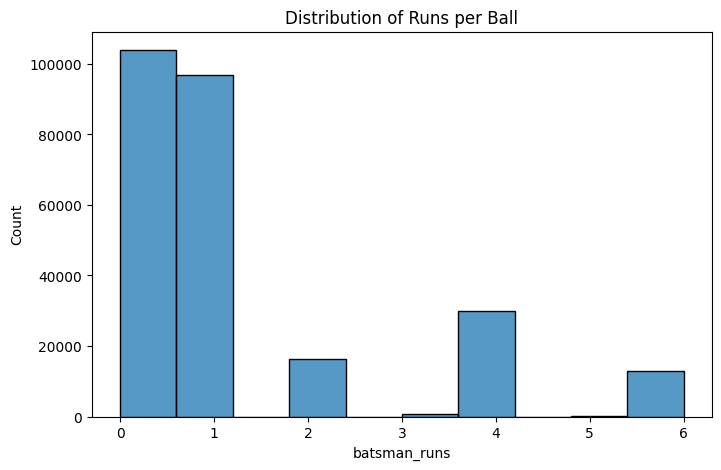

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(deliveries['batsman_runs'], bins=10)
plt.title("Distribution of Runs per Ball")
plt.show()


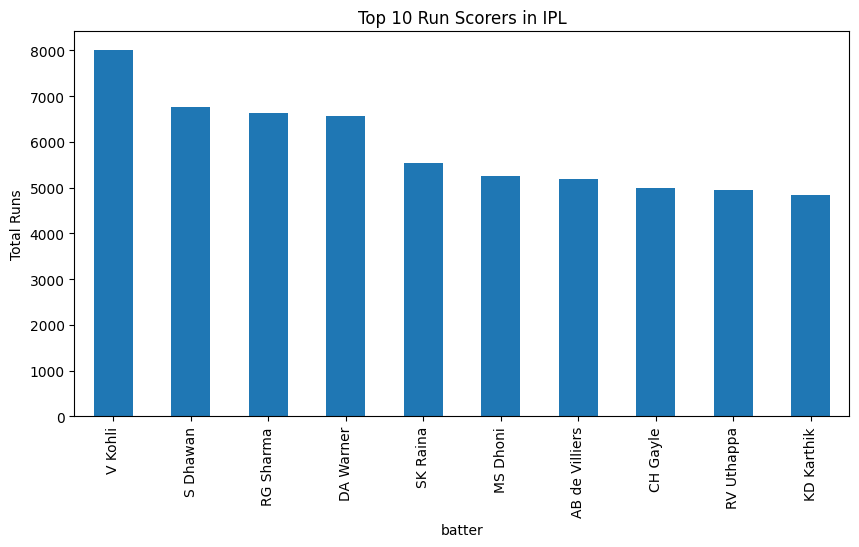

In [19]:
top_batters = deliveries.groupby('batter')['batsman_runs'].sum() \
                        .sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_batters.plot(kind='bar')
plt.title("Top 10 Run Scorers in IPL")
plt.ylabel("Total Runs")
plt.show()


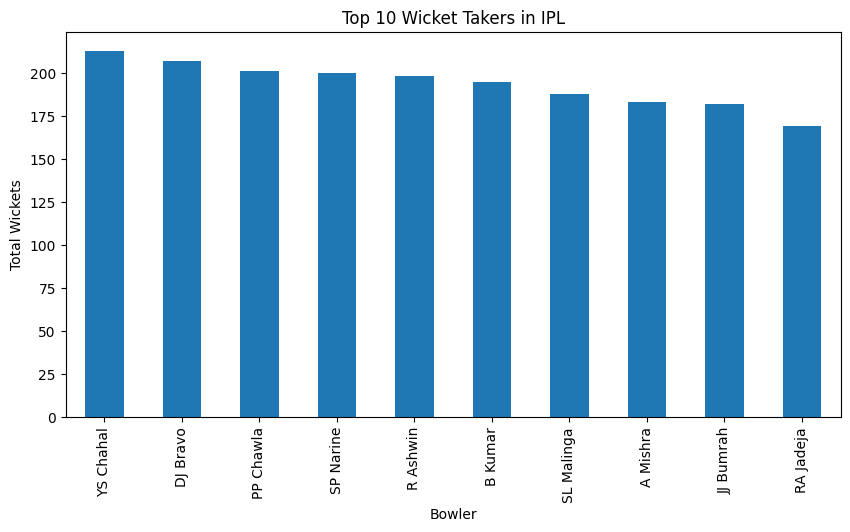

In [21]:
# Top 10 bowlers by wickets
top_bowlers = deliveries.groupby('bowler')['is_wicket'].sum() \
                        .sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_bowlers.plot(kind='bar')
plt.title("Top 10 Wicket Takers in IPL")
plt.ylabel("Total Wickets")
plt.xlabel("Bowler")
plt.show()


EDA – Wickets Distribution

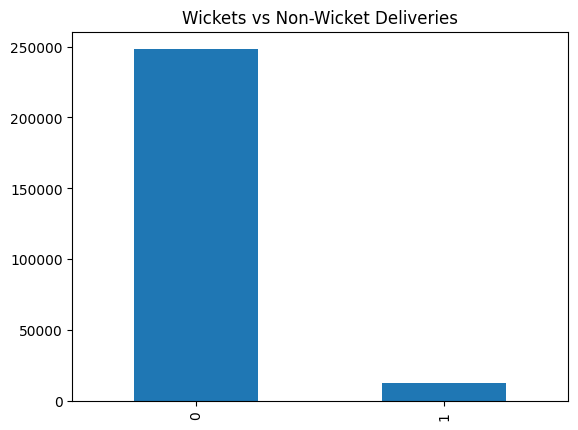

In [22]:
deliveries['is_wicket'].value_counts().plot(kind='bar')
plt.title("Wickets vs Non-Wicket Deliveries")
plt.show()


EDA – Team Performance

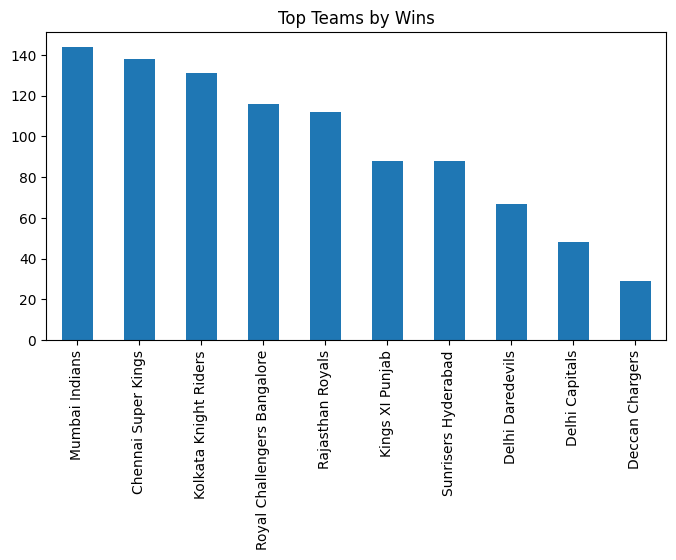

In [24]:
matches['winner'].value_counts().head(10).plot(
    kind='bar',
    figsize=(8,4),
    title="Top Teams by Wins"
)
plt.show()

EDA – Venue Statistics

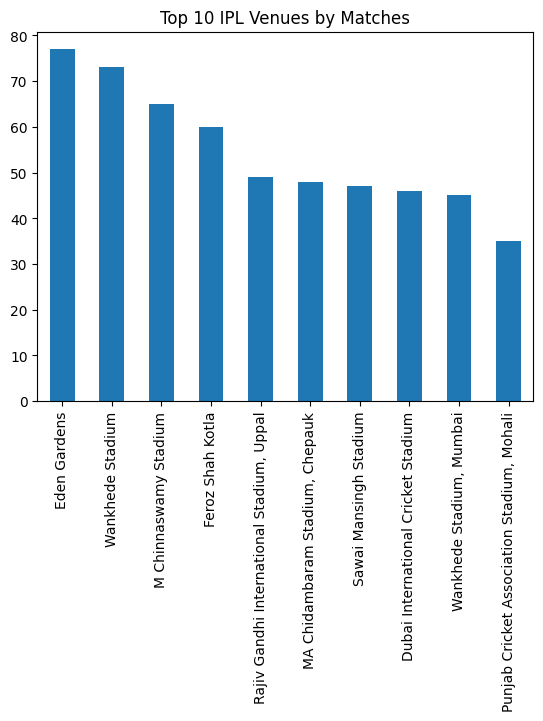

In [23]:
matches['venue'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 IPL Venues by Matches")
plt.show()
